In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ---------------------------------------
# Load MNIST
# ---------------------------------------

transform = transforms.ToTensor()


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


def MNIST_model(batch_size = 64, depth = 1, width = 32, lr = 0.01, num_epoch = 20):

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )



# ---------------------------------------
# Define MLP
# 784 -> 32 -> 10
# ---------------------------------------
    layers = []
    layers.append(nn.Flatten())
    layers.append(nn.Linear(784,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,10))

    model = nn.Sequential(*layers)


    # ---------------------------------------
    # Loss and Optimizer
    # ---------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr
    )

# ---------------------------------------
# Training
# ---------------------------------------

    epochs = num_epoch

    loss_history = []
    for epoch in range(epochs):

        running_loss = 0

        for images, labels in train_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)


    return model, loss_history, test_loader

In [ ]:
# A simple netwrok is trained for MNIST Classification (0-9) using one hidden layer (ReLu activation)
# The training process is well understood. As the number of epochs increase, the test accuracy is observed to be increasing in this case. 
# One thing to mention is that the transition from NumPy to PyTorch is a bit overwhelming

In [16]:
results_batch_size = {}

for  bs in [32, 64, 128]:
    model, losses,_ = MNIST_model(batch_size=bs, num_epoch=30)

    results_batch_size[f"bs={bs}"] = losses

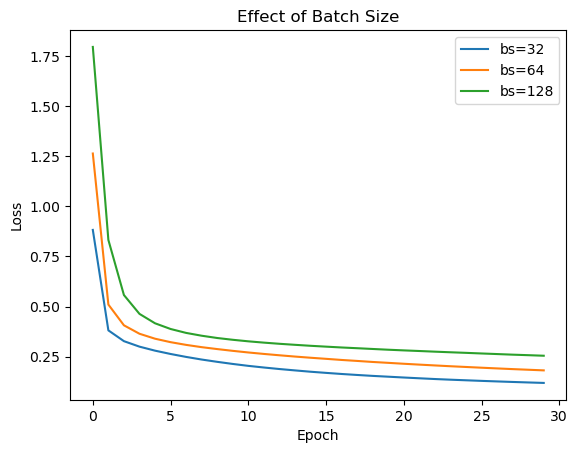

In [17]:
import matplotlib.pyplot as plt
plt.figure()

for name, losses in results_batch_size.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Batch Size")

plt.legend()
plt.show()

In [18]:
results_width_size = {}

for  nw in [32, 64, 128]:
    model, losses,_ = MNIST_model(width=nw, num_epoch=30)

    results_width_size[f"nw={nw}"] = losses

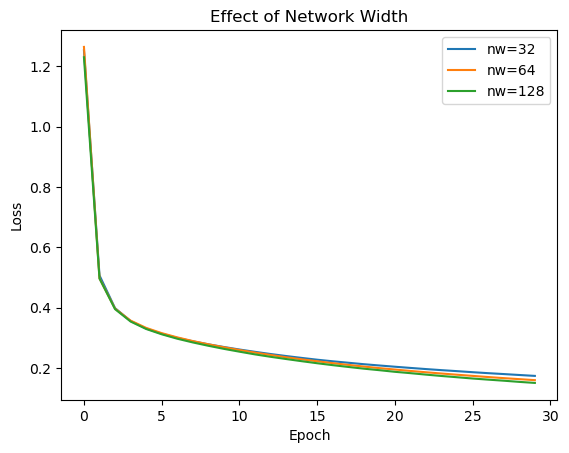

In [19]:
plt.figure()

for name, losses in results_width_size.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Network Width")

plt.legend()
plt.show()

In [20]:
results_depth_size = {}

for  nd in [1, 2, 3]:
    model, losses,_ = MNIST_model(depth=nd, num_epoch=30)

    results_depth_size[f"nd={nd}"] = losses

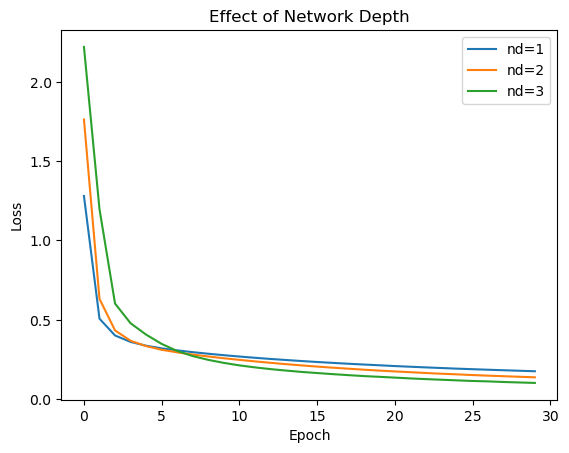

In [21]:
plt.figure()

for name, losses in results_depth_size.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Network Depth")

plt.legend()
plt.show()

In [22]:
results_learn_rate = {}

for  lr in [0.01, 0.05, 0.1]:
    model, losses,_ = MNIST_model(lr=lr, num_epoch=30)

    results_learn_rate[f"lr={lr}"] = losses

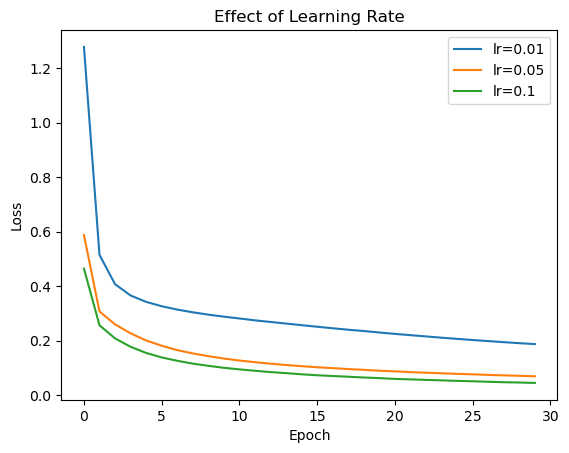

In [23]:
plt.figure()

for name, losses in results_learn_rate.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")

plt.legend()
plt.show()

In [24]:
model, losses,test_loader = MNIST_model(num_epoch=30)

In [27]:
correct = 0
total = 0

wrong_images = []
wrong_preds = []
true_labels = []


with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
            )
        mask = preds != labels

        wrong_images.append(images[mask])
        wrong_preds.append(preds[mask])
        true_labels.append(labels[mask])

        total += labels.size(0)

        correct += (
            preds == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy = {accuracy:.2f}%")


Test Accuracy = 94.81%


In [28]:
wrong_images = torch.cat(wrong_images)
wrong_preds = torch.cat(wrong_preds)
true_labels = torch.cat(true_labels)

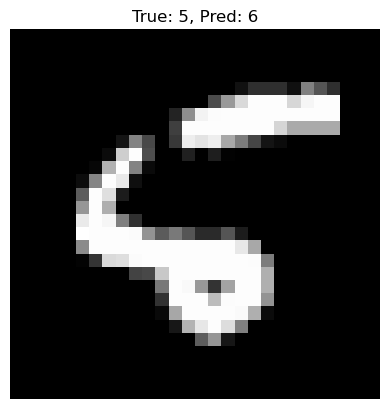

In [38]:
idx = 0  # pick any misclassified example

img = wrong_images[idx].squeeze().cpu().numpy()

plt.imshow(img, cmap='gray')
plt.title(f"True: {true_labels[idx].item()}, Pred: {wrong_preds[idx].item()}")
plt.axis('off')
plt.show()